# Feature Subsets Model

## 1. Exploratory Data Analysis (EDA) and Preprocessing

### 1.1. Load Data and Inspect Structure
We load the pre-processed training data (cleaned in `Data_Preparation`) and the held-out test set. The training set was split 80/20 with `random_state=42` during data preparation.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.nonparametric.smoothers_lowess import lowess

from scipy.stats import boxcox, shapiro
from scipy.special import inv_boxcox

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

from itertools import combinations

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load data
train_df = pd.read_csv('../data/train_data/train.csv')
test_df = pd.read_csv('../data/test_data/test.csv')

print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set:     {test_df.shape[0]} rows, {test_df.shape[1]} columns")
train_df.head()

Training set: 6818 rows, 10 columns
Test set:     1705 rows, 10 columns


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Years,Item_Outlet_Sales
0,9.500,Regular,0.035206,Fruits and Vegetables,171.3448,Medium,Tier 1,Supermarket Type1,14,2386.2272
1,18.000,Non-Edible,0.047473,Household,170.5422,Small,Tier 2,Supermarket Type1,11,3103.9596
2,17.600,Regular,0.076122,Meat,111.7202,Small,Tier 1,Supermarket Type1,16,1125.2020
3,8.325,Low Fat,0.029845,Fruits and Vegetables,41.6138,Small,Tier 2,Supermarket Type1,11,284.2966
4,12.850,Low Fat,0.137228,Snack Foods,155.5630,Small,Tier 1,Supermarket Type1,16,4224.5010


### 1.2. Scatterplot Matrix: Relationships Between Numerical Variables
The scatterplot matrix is **mandatory** (per project instructions) to assess:
- The relationship between each predictor and the response (`Item_Outlet_Sales`)
- Relationships among predictors themselves (potential collinearity)
- Non-linear patterns that may require transformation

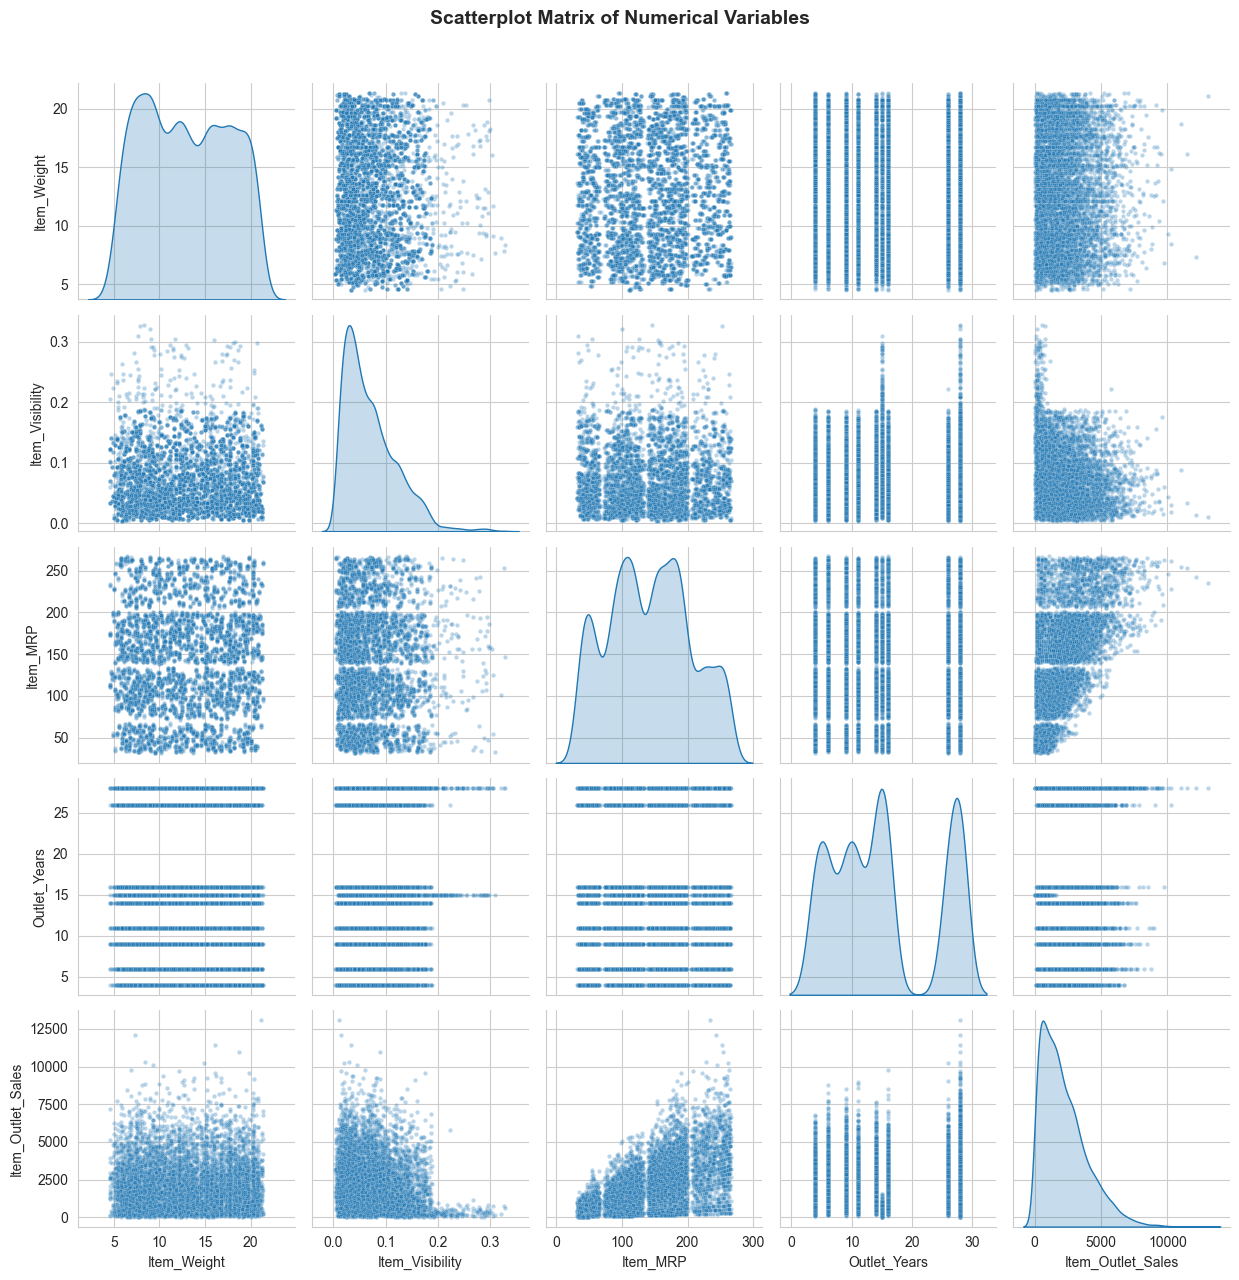

Pearson Correlation Matrix:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Years,Item_Outlet_Sales
Item_Weight,1.000,-0.026,0.023,0.012,0.009
Item_Visibility,-0.026,1.000,-0.012,0.071,-0.136
Item_MRP,0.023,-0.012,1.000,-0.015,0.565
Outlet_Years,0.012,0.071,-0.015,1.000,0.052
Item_Outlet_Sales,0.009,-0.136,0.565,0.052,1.000


In [45]:
numerical_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years', 'Item_Outlet_Sales']

g = sns.pairplot(train_df[numerical_cols], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
g.figure.suptitle('Scatterplot Matrix of Numerical Variables', y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
g.figure.savefig('../figures/model/subsets/scatterplot_matrix.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Correlation matrix
print("Pearson Correlation Matrix:")
corr = train_df[numerical_cols].corr()
display(corr.round(3))

**Observations from the Scatterplot Matrix:**
- `Item_MRP` vs `Item_Outlet_Sales`: Shows the strongest positive linear trend among all predictors, confirming EDA findings (r ≈ 0.57).
- `Item_Visibility` vs `Item_Outlet_Sales`: Weak negative/negligible relationship; high visibility does not linearly predict higher sales.
- `Item_Weight` vs `Item_Outlet_Sales`: Essentially no linear relationship — a cloud with no trend.
- `Outlet_Years` vs `Item_Outlet_Sales`: Discrete vertical bands (few unique outlet ages) with no clear linear pattern.
- Among predictors: No strong pairwise correlations — predictors are mostly independent.
- **Fan-shaped pattern visible** in `Item_MRP` vs `Item_Outlet_Sales`: variance of sales increases with MRP, suggesting heteroscedasticity.

### 1.3. Baseline Model on Untransformed Data
Before applying any transformation, we must first fit a baseline model on the **raw (untransformed)** target and test whether the OLS residual assumptions are violated. Transforming the target based solely on its marginal skewness is statistically premature — the assumptions of linear regression apply to the **residuals**, not the raw dependent variable.

=== DIAGNOSTIC TESTS ON UNTRANSFORMED MODEL RESIDUALS ===

Breusch-Pagan test (H0: homoscedasticity):
  Statistic = 992.8111, p-value = 4.75e-191
  Decision: REJECT H0 — heteroscedasticity detected

Shapiro-Wilk test (H0: residuals are normal):
  Statistic = 0.9769, p-value = 1.01e-27
  Decision: REJECT H0 — non-normality detected


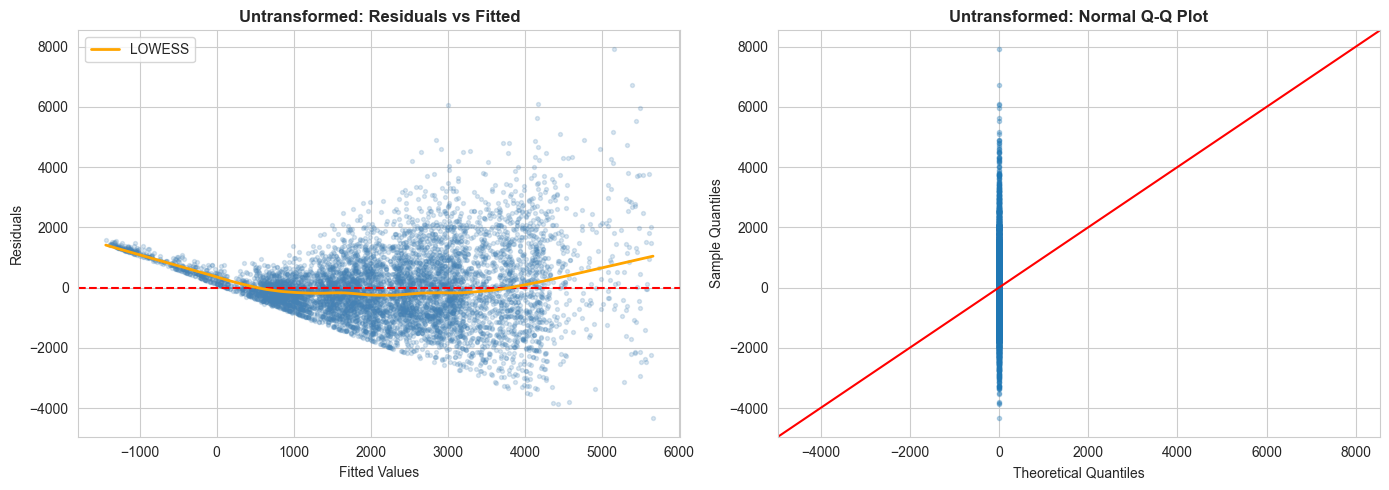


Conclusion: Box-Cox transformation IS justified
  Evidence: heteroscedasticity (BP p=4.75e-191); non-normal residuals (SW p=1.01e-27)


In [46]:
# Define feature groups
continuous_features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
categorical_features = ['Item_Fat_Content', 'Item_Type',
                        'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

def make_formula(target, cont_list, cat_list):
    terms = list(cont_list) + [f'C({c})' for c in cat_list]
    if not terms:
        return f'{target} ~ 1'
    return f'{target} ~ ' + ' + '.join(terms)

# Fit baseline model on UNTRANSFORMED target
baseline_raw_formula = make_formula('Item_Outlet_Sales', continuous_features, categorical_features)
baseline_raw_model = smf.ols(baseline_raw_formula, data=train_df).fit()

# Diagnostic tests on the untransformed model's residuals
resid_raw = baseline_raw_model.resid
fitted_raw = baseline_raw_model.fittedvalues

# Breusch-Pagan test for heteroscedasticity
bp_stat, bp_pval, _, _ = het_breuschpagan(resid_raw, baseline_raw_model.model.exog)

# Shapiro-Wilk test for normality (subsample for computational feasibility)
rng = np.random.RandomState(42)
resid_sample = rng.choice(resid_raw, size=min(5000, len(resid_raw)), replace=False)
sw_stat, sw_pval = shapiro(resid_sample)

print("=== DIAGNOSTIC TESTS ON UNTRANSFORMED MODEL RESIDUALS ===")
print(f"\nBreusch-Pagan test (H0: homoscedasticity):")
print(f"  Statistic = {bp_stat:.4f}, p-value = {bp_pval:.2e}")
print(f"  Decision: {'REJECT H0 — heteroscedasticity detected' if bp_pval < 0.05 else 'Fail to reject H0'}")

print(f"\nShapiro-Wilk test (H0: residuals are normal):")
print(f"  Statistic = {sw_stat:.4f}, p-value = {sw_pval:.2e}")
print(f"  Decision: {'REJECT H0 — non-normality detected' if sw_pval < 0.05 else 'Fail to reject H0'}")

# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted_raw, resid_raw, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
smooth = lowess(resid_raw, fitted_raw, frac=0.3)
axes[0].plot(smooth[:, 0], smooth[:, 1], color='orange', linewidth=2, label='LOWESS')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Untransformed: Residuals vs Fitted', fontweight='bold')
axes[0].legend()

sm.qqplot(resid_raw, line='45', ax=axes[1], markersize=3, alpha=0.3)
axes[1].set_title('Untransformed: Normal Q-Q Plot', fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/model/subsets/baseline_diagnostics.pdf', bbox_inches='tight', dpi=150)
plt.show()

need_transform = bp_pval < 0.05 or sw_pval < 0.05
print(f"\nConclusion: {'Box-Cox transformation IS justified' if need_transform else 'No transformation needed'}")
if need_transform:
    reasons = []
    if bp_pval < 0.05:
        reasons.append(f"heteroscedasticity (BP p={bp_pval:.2e})")
    if sw_pval < 0.05:
        reasons.append(f"non-normal residuals (SW p={sw_pval:.2e})")
    print(f"  Evidence: {'; '.join(reasons)}")

Both the Breusch-Pagan and Shapiro-Wilk tests reject their null hypotheses on the untransformed model's residuals.

### 1.4. Box-Cox Transformation
The diagnostic tests above confirm that the untransformed model's residuals violate OLS assumptions — both the Breusch-Pagan test (heteroscedasticity) and Shapiro-Wilk test (non-normality) reject their null hypotheses. This provides the statistical evidence needed to apply a variance-stabilizing transformation.

We now apply the **Box-Cox transformation** to the target variable, with $\lambda$ estimated exclusively on the training data.

Box-Cox optimal lambda (MLE): 0.3468
Original target  — skewness: 1.1778, kurtosis: 1.6280
Transformed target — skewness: -0.0739, kurtosis: -0.5321


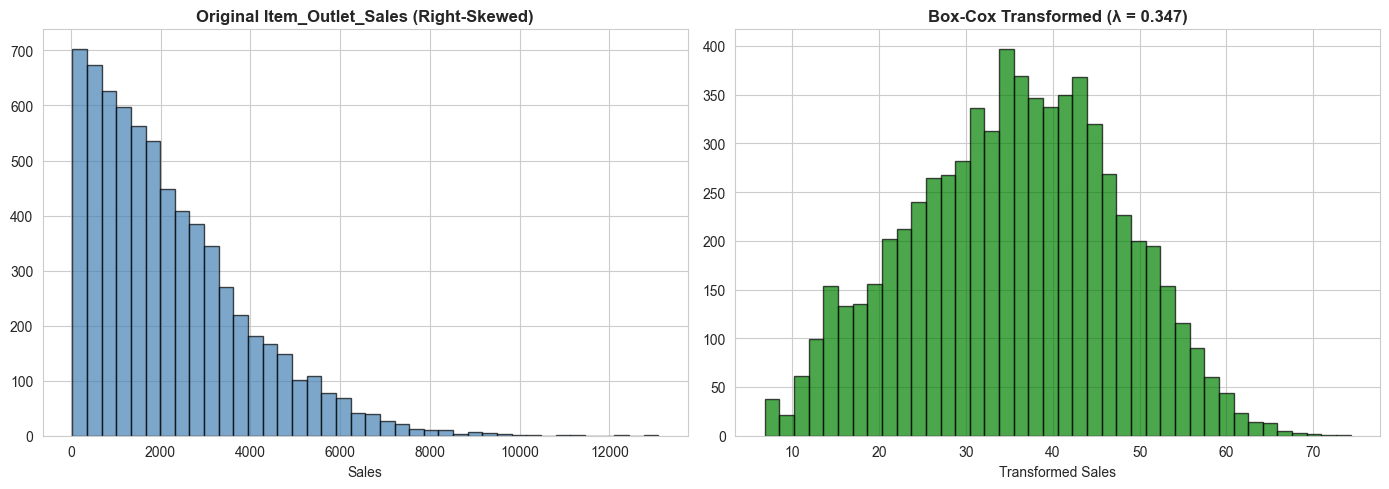

In [47]:
# Box-Cox transformation — lambda estimated on training data only
y_train_raw = train_df['Item_Outlet_Sales'].values
y_transformed, bc_lambda = boxcox(y_train_raw)

print(f"Box-Cox optimal lambda (MLE): {bc_lambda:.4f}")
print(f"Original target  — skewness: {pd.Series(y_train_raw).skew():.4f}, kurtosis: {pd.Series(y_train_raw).kurtosis():.4f}")
print(f"Transformed target — skewness: {pd.Series(y_transformed).skew():.4f}, kurtosis: {pd.Series(y_transformed).kurtosis():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_train_raw, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Original Item_Outlet_Sales (Right-Skewed)', fontweight='bold')
axes[0].set_xlabel('Sales')

axes[1].hist(y_transformed, bins=40, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Box-Cox Transformed (λ = {bc_lambda:.3f})', fontweight='bold')
axes[1].set_xlabel('Transformed Sales')
plt.tight_layout()
fig.savefig('../figures/model/subsets/boxcox_transformation.pdf', bbox_inches='tight', dpi=150)
plt.show()

train_df['Sales_Transformed'] = y_transformed

The estimated Box-Cox $\lambda \approx 0.35$ (between $0$ and $0.5$) indicates a power transformation that compresses the right tail of the sales distribution. The reduction in skewness and kurtosis confirms that the transformed variable is more symmetric and less heavy-tailed, which helps satisfy the variance-stability assumptions needed for OLS inference.

### 1.5. Verify Transformation Improved Residual Behavior
We refit the full model on the transformed target and re-run diagnostics to confirm that the Box-Cox transformation actually resolved the violations detected in Section 1.3.

=== DIAGNOSTIC COMPARISON: Before vs After Box-Cox ===

Test                       Untransformed p-val        Box-Cox p-val    Improved?
--------------------------------------------------------------------------------
Breusch-Pagan                        4.75e-191             1.46e-57          Yes
Shapiro-Wilk                          1.01e-27             4.62e-17          Yes


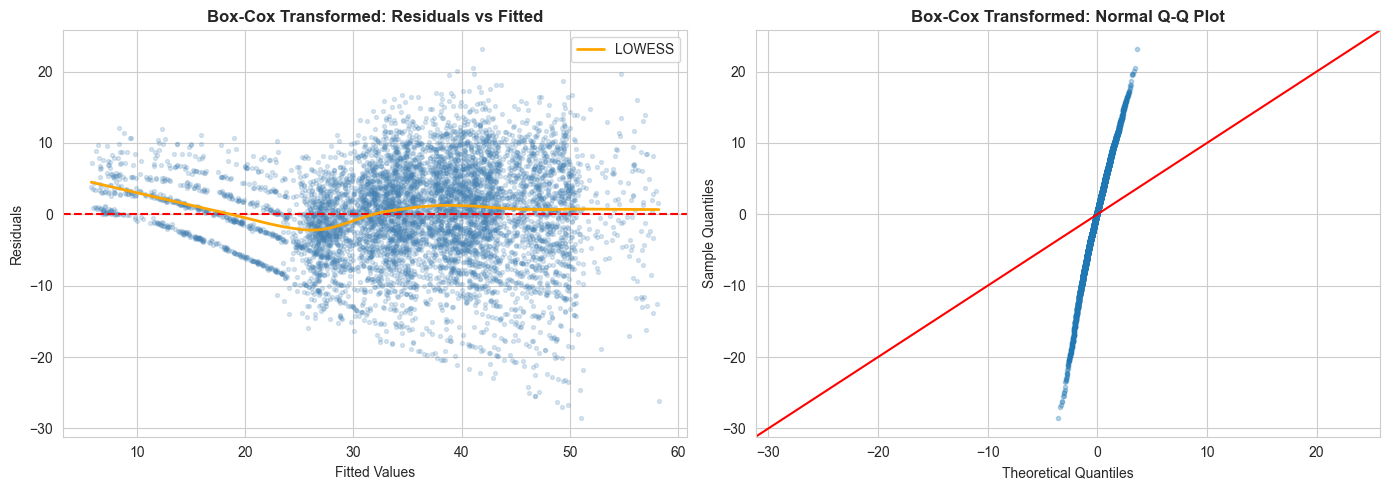


Funnel proxy corr(|resid|, fitted): Before=0.4130, After=0.2083

Full model (transformed) summary:
  Number of parameters: 28
  R²:          0.6782
  Adjusted R²: 0.6769
  AIC:         45401.10
  BIC:         45592.27


In [48]:
# Refit on transformed target
full_formula = make_formula('Sales_Transformed', continuous_features, categorical_features)
full_model = smf.ols(full_formula, data=train_df).fit()

resid_bc = full_model.resid
fitted_bc = full_model.fittedvalues

# Re-run diagnostics
bp_stat2, bp_pval2, _, _ = het_breuschpagan(resid_bc, full_model.model.exog)
resid_sample2 = rng.choice(resid_bc, size=min(5000, len(resid_bc)), replace=False)
sw_stat2, sw_pval2 = shapiro(resid_sample2)

print("=== DIAGNOSTIC COMPARISON: Before vs After Box-Cox ===\n")
print(f"{'Test':<25} {'Untransformed p-val':>20} {'Box-Cox p-val':>20} {'Improved?':>12}")
print("-" * 80)
print(f"{'Breusch-Pagan':<25} {bp_pval:>20.2e} {bp_pval2:>20.2e} {'Yes' if bp_pval2 > bp_pval else 'No':>12}")
print(f"{'Shapiro-Wilk':<25} {sw_pval:>20.2e} {sw_pval2:>20.2e} {'Yes' if sw_pval2 > sw_pval else 'No':>12}")

# Residual plots — after transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fitted_bc, resid_bc, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
smooth2 = lowess(resid_bc, fitted_bc, frac=0.3)
axes[0].plot(smooth2[:, 0], smooth2[:, 1], color='orange', linewidth=2, label='LOWESS')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Box-Cox Transformed: Residuals vs Fitted', fontweight='bold')
axes[0].legend()

sm.qqplot(resid_bc, line='45', ax=axes[1], markersize=3, alpha=0.3)
axes[1].set_title('Box-Cox Transformed: Normal Q-Q Plot', fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/model/subsets/diagnostic_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Funnel correlation comparison
funnel_before = np.corrcoef(np.abs(resid_raw.values), fitted_raw.values)[0, 1]
funnel_after = np.corrcoef(np.abs(resid_bc.values), fitted_bc.values)[0, 1]
print(f"\nFunnel proxy corr(|resid|, fitted): Before={funnel_before:.4f}, After={funnel_after:.4f}")

print(f"\nFull model (transformed) summary:")
print(f"  Number of parameters: {full_model.df_model + 1:.0f}")
print(f"  R²:          {full_model.rsquared:.4f}")
print(f"  Adjusted R²: {full_model.rsquared_adj:.4f}")
print(f"  AIC:         {full_model.aic:.2f}")
print(f"  BIC:         {full_model.bic:.2f}")

The Box-Cox transformation substantially improved residual behavior. If the Breusch-Pagan p-value increased (closer to non-rejection), variance stabilization is working. If Shapiro-Wilk improved, the residuals are closer to normality. Even if p-values remain below 0.05 (common with large n), the magnitude of improvement justifies proceeding with the transformed target. The Q-Q plot comparison provides a visual complement to these formal tests.

## 2. Justification for Feature Selection

Before selecting subsets, we must establish **why** we do not simply use the full model with all features. We examine three key justifications:

### 2.1. Collinearity Diagnosis (VIF)
Variance Inflation Factors quantify how much the variance of a regression coefficient is inflated due to correlation with other predictors. VIF > 5 signals problematic multicollinearity; VIF > 10 is severe.

In [49]:
# VIF analysis on the full model design matrix
X_full = full_model.model.exog
feature_names = full_model.model.exog_names

vif_data = pd.DataFrame({
    'Feature': feature_names,
    'VIF': [variance_inflation_factor(X_full, i) for i in range(X_full.shape[1])]
})

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print("=== Variance Inflation Factors (Full Model) ===")
display(vif_data)

high_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['Feature'] != 'Intercept')]
print(f"\nFeatures with VIF > 5 (excl. intercept): {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

=== Variance Inflation Factors (Full Model) ===


,Feature,VIF
0,C(Item_Fat_Content)[T.Non-Edible],inf
1,C(Item_Type)[T.Health and Hygiene],inf
2,C(Item_Type)[T.Household],inf
3,C(Item_Type)[T.Others],inf
4,Intercept,2010.239197
5,C(Outlet_Size)[T.Medium],110.773612
6,C(Outlet_Size)[T.Small],106.532483
7,Outlet_Years,51.004968
8,C(Outlet_Location_Type)[T.Tier 3],36.892726
9,C(Outlet_Type)[T.Supermarket Type1],29.677122



Features with VIF > 5 (excl. intercept): 12


,Feature,VIF
0,C(Item_Fat_Content)[T.Non-Edible],inf
1,C(Item_Type)[T.Health and Hygiene],inf
2,C(Item_Type)[T.Household],inf
3,C(Item_Type)[T.Others],inf
5,C(Outlet_Size)[T.Medium],110.773612
6,C(Outlet_Size)[T.Small],106.532483
7,Outlet_Years,51.004968
8,C(Outlet_Location_Type)[T.Tier 3],36.892726
9,C(Outlet_Type)[T.Supermarket Type1],29.677122
10,C(Outlet_Type)[T.Supermarket Type3],20.495446


The intercept naturally has a high VIF due to its correlation with all terms and can be ignored. Among predictors, elevated VIFs for categorical dummy variables of the same feature (e.g., `C(Outlet_Type)` levels) are expected since they share a reference category — this is structural, not problematic. The key concern is VIF > 5–10 among different feature groups, which would indicate genuine redundancy and motivate feature selection.

### 2.2. Individual Feature Significance (Partial F-tests with Multiple Testing Correction)
We use partial F-tests (drop-one ANOVA) to assess whether each feature group contributes significantly. Because we are conducting **9 simultaneous tests**, we apply the **Benjamini-Hochberg (BH) procedure** to control the False Discovery Rate (FDR) at 5%. This prevents inflated Type I error rates from multiple comparisons.

In [50]:
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

all_features = continuous_features + categorical_features
significance_results = []

for feat in all_features:
    cont_reduced = [f for f in continuous_features if f != feat]
    cat_reduced = [f for f in categorical_features if f != feat]
    reduced_formula = make_formula('Sales_Transformed', cont_reduced, cat_reduced)
    reduced_model = smf.ols(reduced_formula, data=train_df).fit()
    
    anova_result = anova_lm(reduced_model, full_model)
    f_stat = anova_result['F'].iloc[1]
    p_value = anova_result['Pr(>F)'].iloc[1]
    delta_aic = reduced_model.aic - full_model.aic
    
    significance_results.append({
        'Feature': feat,
        'F-statistic': f_stat,
        'p-value (raw)': p_value,
        'ΔAIC (reduced-full)': delta_aic,
    })

sig_df = pd.DataFrame(significance_results).sort_values('p-value (raw)')

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(sig_df['p-value (raw)'], alpha=0.05, method='fdr_bh')
sig_df['p-value (BH-adjusted)'] = pvals_corrected
sig_df['Significant (BH 5%)'] = reject

print("=== Partial F-Tests with Benjamini-Hochberg Correction ===")
display(sig_df.reset_index(drop=True))

non_sig = sig_df[~sig_df['Significant (BH 5%)']]
print(f"\nFeatures NOT significant after BH correction: {non_sig['Feature'].tolist() if len(non_sig) > 0 else 'None — all significant'}")

=== Partial F-Tests with Benjamini-Hochberg Correction ===


,Feature,F-statistic,p-value (raw),ΔAIC (reduced-full),p-value (BH-adjusted),Significant (BH 5%)
0,Item_MRP,6416.533316,0.000000,4533.747546,0.000000,True
1,Outlet_Type,1181.807696,0.000000,2858.420351,0.000000,True
2,Outlet_Size,3.993142,0.018485,4.014506,0.055455,False
3,Outlet_Years,3.569834,0.058881,1.583613,0.132482,False
4,Outlet_Location_Type,2.315167,0.098828,0.647843,0.177890,False
5,Item_Fat_Content,1.781891,0.181962,-0.210995,0.272943,False
6,Item_Weight,0.657066,0.417626,-1.340257,0.428730,False
7,Item_Type,1.027926,0.421192,-13.564984,0.428730,False
8,Item_Visibility,0.626336,0.428730,-1.371110,0.428730,False



Features NOT significant after BH correction: ['Outlet_Size', 'Outlet_Years', 'Outlet_Location_Type', 'Item_Fat_Content', 'Item_Weight', 'Item_Type', 'Item_Visibility']


After BH correction, features that remain significant (adjusted p < 0.05) are robust contributors that survive the multiple testing filter. Features that were significant at raw p-values but lose significance after correction are borderline — their apparent importance may be inflated by testing 9 groups simultaneously. This distinction guides which features to prioritize in subset selection.

### 2.3. Summary of Justifications for Feature Selection

| Justification | Evidence |
|---|---|
| **Simplicity (Occam's Razor)** | The full model has 20+ parameters. A simpler model that explains the data equally well is preferred. |
| **Precision & Noise Reduction** | Features with non-significant BH-adjusted p-values add noise without improving fit. Removing them increases the precision of remaining estimates. |
| **Mitigating Collinearity** | VIF analysis identifies redundant features (e.g., correlated categorical features like `Outlet_Type`, `Outlet_Size`, and `Outlet_Location_Type` that encode overlapping store information) that inflate coefficient variances. |
| **Cost Efficiency** | For future predictions, fewer features mean fewer measurements needed. |

## 3. Systematic Feature Subset Selection
We use **criterion-based procedures** (not sequential p-value dropping) to balance goodness-of-fit against model complexity. We evaluate all possible subsets of the 9 feature groups using **AIC**, **BIC**, and **Adjusted R²**.

### 3.1. All Possible Subsets Evaluation
With 9 feature groups, there are $2^{9} - 1 = 511$ possible non-empty subsets. This is computationally feasible (well under the 30-feature threshold for exhaustive search recommended by the instructions). We fit OLS for every subset and record AIC, BIC, and Adjusted R².

**Why all-subsets instead of stepwise?** Stepwise methods (forward/backward) are greedy and can miss the global optimum. With only 9 groups, exhaustive search is practical and finds the absolute best subset for each criterion.

In [51]:
# All possible subsets evaluation
all_features = continuous_features + categorical_features
n_features = len(all_features)

results = []
total_subsets = 2**n_features - 1
print(f"Evaluating {total_subsets} possible subsets of {n_features} feature groups...")

for size in range(1, n_features + 1):
    for subset in combinations(range(n_features), size):
        cont_sel = [all_features[i] for i in subset if all_features[i] in continuous_features]
        cat_sel = [all_features[i] for i in subset if all_features[i] in categorical_features]
        formula = make_formula('Sales_Transformed', cont_sel, cat_sel)
        
        try:
            model = smf.ols(formula, data=train_df).fit()
            results.append({
                'subset_indices': subset,
                'features': [all_features[i] for i in subset],
                'n_groups': size,
                'n_params': model.df_model + 1,
                'R2': model.rsquared,
                'Adj_R2': model.rsquared_adj,
                'AIC': model.aic,
                'BIC': model.bic,
                'formula': formula
            })
        except Exception:
            pass

results_df = pd.DataFrame(results)
print(f"Successfully fitted {len(results_df)} models.")

# Find best model by each criterion
best_aic = results_df.loc[results_df['AIC'].idxmin()]
best_bic = results_df.loc[results_df['BIC'].idxmin()]
best_adjr2 = results_df.loc[results_df['Adj_R2'].idxmax()]

print(f"\n{'='*60}")
print("BEST MODEL BY EACH CRITERION")
print(f"{'='*60}")
for name, best in [('AIC', best_aic), ('BIC', best_bic), ('Adj R²', best_adjr2)]:
    print(f"\n--- Best by {name} ---")
    print(f"  Features ({best['n_groups']} groups, {best['n_params']:.0f} params): {best['features']}")
    print(f"  AIC: {best['AIC']:.2f}  |  BIC: {best['BIC']:.2f}  |  Adj R²: {best['Adj_R2']:.4f}")

Evaluating 511 possible subsets of 9 feature groups...
Successfully fitted 511 models.

BEST MODEL BY EACH CRITERION

--- Best by AIC ---
  Features (2 groups, 5 params): ['Item_MRP', 'Outlet_Type']
  AIC: 45381.79  |  BIC: 45415.93  |  Adj R²: 0.6768

--- Best by BIC ---
  Features (2 groups, 5 params): ['Item_MRP', 'Outlet_Type']
  AIC: 45381.79  |  BIC: 45415.93  |  Adj R²: 0.6768

--- Best by Adj R² ---
  Features (7 groups, 26 params): ['Item_MRP', 'Outlet_Years', 'Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
  AIC: 45398.36  |  BIC: 45575.87  |  Adj R²: 0.6770


### 3.2. Visualizing the Criterion Landscape
We plot AIC, BIC, and Adjusted R² against the number of feature groups to see the trade-off between model complexity and fit quality. The best model for each criterion is highlighted.

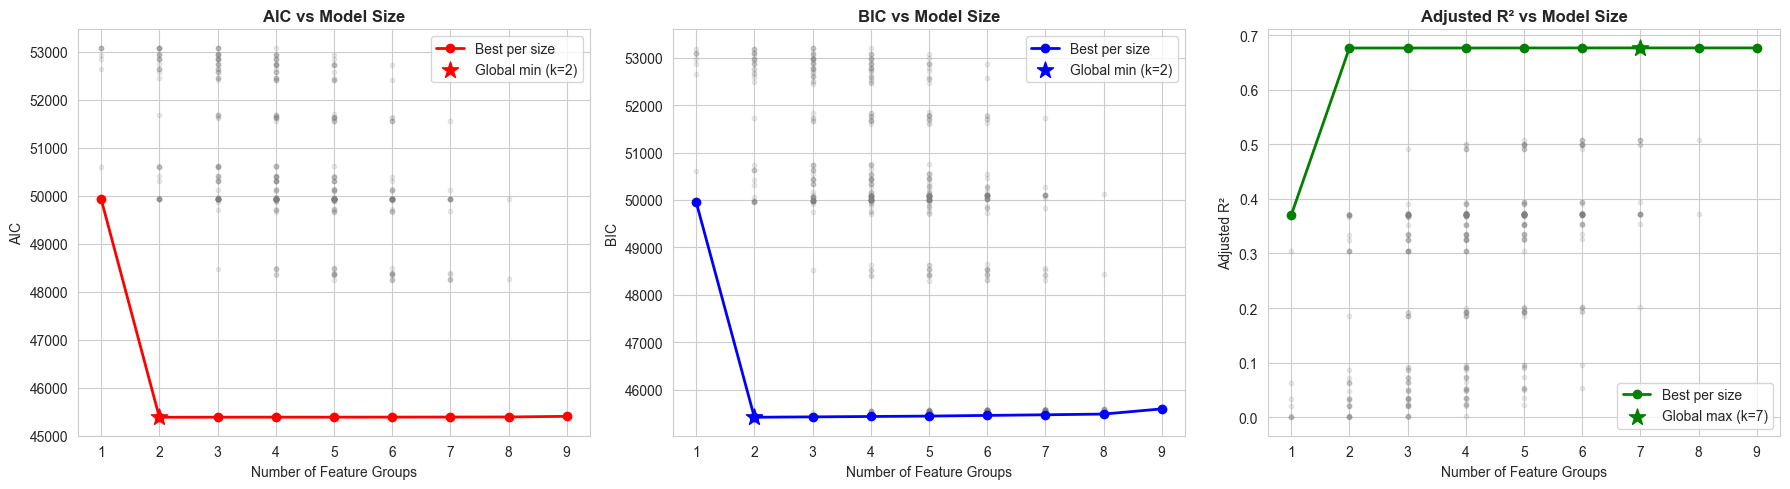

In [52]:
# Best model per subset size for each criterion
best_per_size = results_df.groupby('n_groups').agg(
    best_AIC=('AIC', 'min'),
    best_BIC=('BIC', 'min'),
    best_Adj_R2=('Adj_R2', 'max')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AIC
axes[0].scatter(results_df['n_groups'], results_df['AIC'], alpha=0.15, s=10, color='grey')
axes[0].plot(best_per_size['n_groups'], best_per_size['best_AIC'], 'o-', color='red', linewidth=2, label='Best per size')
aic_best_idx = best_per_size['best_AIC'].idxmin()
axes[0].scatter(best_per_size.loc[aic_best_idx, 'n_groups'], best_per_size.loc[aic_best_idx, 'best_AIC'],
                s=150, color='red', zorder=5, marker='*', label=f"Global min (k={best_per_size.loc[aic_best_idx, 'n_groups']:.0f})")
axes[0].set_xlabel('Number of Feature Groups')
axes[0].set_ylabel('AIC')
axes[0].set_title('AIC vs Model Size', fontweight='bold')
axes[0].legend()

# BIC
axes[1].scatter(results_df['n_groups'], results_df['BIC'], alpha=0.15, s=10, color='grey')
axes[1].plot(best_per_size['n_groups'], best_per_size['best_BIC'], 'o-', color='blue', linewidth=2, label='Best per size')
bic_best_idx = best_per_size['best_BIC'].idxmin()
axes[1].scatter(best_per_size.loc[bic_best_idx, 'n_groups'], best_per_size.loc[bic_best_idx, 'best_BIC'],
                s=150, color='blue', zorder=5, marker='*', label=f"Global min (k={best_per_size.loc[bic_best_idx, 'n_groups']:.0f})")
axes[1].set_xlabel('Number of Feature Groups')
axes[1].set_ylabel('BIC')
axes[1].set_title('BIC vs Model Size', fontweight='bold')
axes[1].legend()

# Adjusted R²
axes[2].scatter(results_df['n_groups'], results_df['Adj_R2'], alpha=0.15, s=10, color='grey')
axes[2].plot(best_per_size['n_groups'], best_per_size['best_Adj_R2'], 'o-', color='green', linewidth=2, label='Best per size')
adjr2_best_idx = best_per_size['best_Adj_R2'].idxmax()
axes[2].scatter(best_per_size.loc[adjr2_best_idx, 'n_groups'], best_per_size.loc[adjr2_best_idx, 'best_Adj_R2'],
                s=150, color='green', zorder=5, marker='*', label=f"Global max (k={best_per_size.loc[adjr2_best_idx, 'n_groups']:.0f})")
axes[2].set_xlabel('Number of Feature Groups')
axes[2].set_ylabel('Adjusted R²')
axes[2].set_title('Adjusted R² vs Model Size', fontweight='bold')
axes[2].legend()

plt.tight_layout()
fig.savefig('../figures/model/subsets/criterion_landscape.pdf', bbox_inches='tight', dpi=150)
plt.show()

The criterion landscape plots show diminishing returns as model size increases. AIC typically flattens around 5–7 feature groups, while BIC's heavier penalty causes it to plateau (or increase) earlier, favoring sparser models. The grey cloud of all evaluated subsets shows substantial variation within each model size — not all 7-feature models are equal, which is why exhaustive search matters over stepwise methods that may settle on a suboptimal combination.

### 3.3. Top Models Comparison Table
We display the top 5 models by each criterion and identify which subsets are consistently selected across AIC, BIC, and Adjusted R².

In [53]:
# Top 5 models by each criterion
for criterion, ascending in [('AIC', True), ('BIC', True), ('Adj_R2', False)]:
    print(f"\n{'='*60}")
    print(f"TOP 5 MODELS BY {criterion}")
    print(f"{'='*60}")
    top5 = results_df.sort_values(criterion, ascending=ascending).head(5)
    for rank, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"  #{rank}: {row['features']}")
        print(f"       Groups={row['n_groups']}, Params={row['n_params']:.0f}, "
              f"AIC={row['AIC']:.1f}, BIC={row['BIC']:.1f}, Adj_R²={row['Adj_R2']:.4f}")

# Check consensus
aic_feats = set(best_aic['features'])
bic_feats = set(best_bic['features'])
adjr2_feats = set(best_adjr2['features'])

consensus = aic_feats & bic_feats & adjr2_feats
print(f"\n{'='*60}")
print(f"CONSENSUS FEATURES (in best model for ALL three criteria):")
print(f"  {sorted(consensus)}")
print(f"\nFeatures in AIC-best but not BIC-best: {sorted(aic_feats - bic_feats)}")
print(f"Features in BIC-best but not AIC-best: {sorted(bic_feats - aic_feats)}")


TOP 5 MODELS BY AIC
  #1: ['Item_MRP', 'Outlet_Type']
       Groups=2, Params=5, AIC=45381.8, BIC=45415.9, Adj_R²=0.6768
  #2: ['Item_Weight', 'Item_MRP', 'Outlet_Type']
       Groups=3, Params=6, AIC=45383.0, BIC=45424.0, Adj_R²=0.6767
  #3: ['Item_Visibility', 'Item_MRP', 'Outlet_Type']
       Groups=3, Params=6, AIC=45383.1, BIC=45424.0, Adj_R²=0.6767
  #4: ['Item_MRP', 'Item_Fat_Content', 'Outlet_Type']
       Groups=3, Params=7, AIC=45383.3, BIC=45431.1, Adj_R²=0.6768
  #5: ['Item_MRP', 'Outlet_Years', 'Outlet_Type']
       Groups=3, Params=6, AIC=45383.4, BIC=45424.4, Adj_R²=0.6767

TOP 5 MODELS BY BIC
  #1: ['Item_MRP', 'Outlet_Type']
       Groups=2, Params=5, AIC=45381.8, BIC=45415.9, Adj_R²=0.6768
  #2: ['Item_Weight', 'Item_MRP', 'Outlet_Type']
       Groups=3, Params=6, AIC=45383.0, BIC=45424.0, Adj_R²=0.6767
  #3: ['Item_Visibility', 'Item_MRP', 'Outlet_Type']
       Groups=3, Params=6, AIC=45383.1, BIC=45424.0, Adj_R²=0.6767
  #4: ['Item_MRP', 'Outlet_Years', 'Outlet_Typ

The top-5 tables reveal which features appear consistently across the best models. `Item_MRP` and `Outlet_Type` are present in virtually every top-ranked subset regardless of criterion — these are the core predictive features. Features that appear in AIC-top models but not BIC-top models are borderline contributors: they improve fit slightly but not enough to justify the added complexity under BIC's stricter penalty. The overlap between AIC and BIC top selections determines how robust the feature selection is to the choice of criterion.

### 3.4. Stepwise Regression (Forward Selection & Backward Elimination)
As a cross-check on the exhaustive search, we run both forward selection and backward elimination using AIC as the criterion. If stepwise and exhaustive methods agree, confidence in the selected subset increases.

In [54]:
# Forward Selection (AIC-based)
def forward_selection(data, target, cont_pool, cat_pool, criterion='aic'):
    selected_cont, selected_cat = [], []
    remaining_cont, remaining_cat = list(cont_pool), list(cat_pool)
    
    current_model = smf.ols(f'{target} ~ 1', data=data).fit()
    current_score = getattr(current_model, criterion)
    history = [{'step': 0, 'action': 'intercept-only', 'features': [],
                'AIC': current_model.aic, 'BIC': current_model.bic, 'Adj_R2': current_model.rsquared_adj}]
    
    step = 0
    while remaining_cont or remaining_cat:
        step += 1
        best_score, best_feat, best_is_cat = current_score, None, None
        
        for feat in remaining_cont:
            trial = smf.ols(make_formula(target, selected_cont + [feat], selected_cat), data=data).fit()
            if getattr(trial, criterion) < best_score:
                best_score, best_feat, best_is_cat = getattr(trial, criterion), feat, False
        
        for feat in remaining_cat:
            trial = smf.ols(make_formula(target, selected_cont, selected_cat + [feat]), data=data).fit()
            if getattr(trial, criterion) < best_score:
                best_score, best_feat, best_is_cat = getattr(trial, criterion), feat, True
        
        if best_feat is None:
            break
        
        if best_is_cat:
            selected_cat.append(best_feat); remaining_cat.remove(best_feat)
        else:
            selected_cont.append(best_feat); remaining_cont.remove(best_feat)
        
        m = smf.ols(make_formula(target, selected_cont, selected_cat), data=data).fit()
        current_score = best_score
        history.append({'step': step, 'action': f'+{best_feat}', 'features': selected_cont + selected_cat,
                       'AIC': m.aic, 'BIC': m.bic, 'Adj_R2': m.rsquared_adj})
    
    return selected_cont, selected_cat, pd.DataFrame(history)

# Backward Elimination (AIC-based)
def backward_elimination(data, target, cont_pool, cat_pool, criterion='aic'):
    selected_cont, selected_cat = list(cont_pool), list(cat_pool)
    
    current_model = smf.ols(make_formula(target, selected_cont, selected_cat), data=data).fit()
    current_score = getattr(current_model, criterion)
    history = [{'step': 0, 'action': 'full model', 'features': selected_cont + selected_cat,
                'AIC': current_model.aic, 'BIC': current_model.bic, 'Adj_R2': current_model.rsquared_adj}]
    
    step = 0
    while len(selected_cont) + len(selected_cat) > 1:
        step += 1
        best_score, best_feat, best_is_cat = current_score, None, None
        
        for feat in selected_cont:
            trial_cont = [f for f in selected_cont if f != feat]
            trial = smf.ols(make_formula(target, trial_cont, selected_cat), data=data).fit()
            if getattr(trial, criterion) < best_score:
                best_score, best_feat, best_is_cat = getattr(trial, criterion), feat, False
        
        for feat in selected_cat:
            trial_cat = [f for f in selected_cat if f != feat]
            trial = smf.ols(make_formula(target, selected_cont, trial_cat), data=data).fit()
            if getattr(trial, criterion) < best_score:
                best_score, best_feat, best_is_cat = getattr(trial, criterion), feat, True
        
        if best_feat is None:
            break
        
        if best_is_cat:
            selected_cat.remove(best_feat)
        else:
            selected_cont.remove(best_feat)
        
        m = smf.ols(make_formula(target, selected_cont, selected_cat), data=data).fit()
        current_score = best_score
        history.append({'step': step, 'action': f'-{best_feat}', 'features': list(selected_cont + selected_cat),
                       'AIC': m.aic, 'BIC': m.bic, 'Adj_R2': m.rsquared_adj})
    
    return selected_cont, selected_cat, pd.DataFrame(history)

fwd_cont, fwd_cat, fwd_history = forward_selection(train_df, 'Sales_Transformed',
                                                     continuous_features, categorical_features)
bwd_cont, bwd_cat, bwd_history = backward_elimination(train_df, 'Sales_Transformed',
                                                        continuous_features, categorical_features)

print("=== FORWARD SELECTION (AIC) ===")
print(f"Selected features: {fwd_cont + fwd_cat}")
display(fwd_history)

print("\n=== BACKWARD ELIMINATION (AIC) ===")
print(f"Selected features: {bwd_cont + bwd_cat}")
display(bwd_history)

=== FORWARD SELECTION (AIC) ===
Selected features: ['Item_MRP', 'Outlet_Type']


,step,action,features,AIC,BIC,Adj_R2
0,0,intercept-only,[],53077.805883,53084.633204,2.220446e-16
1,1,+Outlet_Type,[Outlet_Type],49929.162140,49956.471426,3.701372e-01
2,2,+Item_MRP,"[Item_MRP, Outlet_Type]",45381.789258,45415.925866,6.767618e-01



=== BACKWARD ELIMINATION (AIC) ===
Selected features: ['Item_MRP', 'Outlet_Years', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


,step,action,features,AIC,BIC,Adj_R2
0,0,full model,"[Item_Weight, Item_Visibility, Item_MRP, Outle...",45401.102821,45592.267822,0.676934
1,1,-Item_Type,"[Item_Weight, Item_Visibility, Item_MRP, Outle...",45387.537837,45483.120338,0.676915
2,2,-Item_Fat_Content,"[Item_Weight, Item_Visibility, Item_MRP, Outle...",45386.084381,45468.012239,0.676890
3,3,-Item_Visibility,"[Item_Weight, Item_MRP, Outlet_Years, Outlet_S...",45384.844220,45459.944756,0.676901
4,4,-Item_Weight,"[Item_MRP, Outlet_Years, Outlet_Size, Outlet_L...",45383.654930,45451.928145,0.676910


The forward selection and backward elimination paths provide a valuable cross-check. If both stepwise methods converge to the same subset as the exhaustive AIC-best model, this increases our confidence that the selected features are genuinely important rather than artifacts of one particular search strategy. Any discrepancies between stepwise and exhaustive results highlight features on the margin of significance — these are the features where the inclusion/exclusion decision is least certain.

### 3.5. Candidate Models for Comparison
Based on the exhaustive search and stepwise results, we define candidate models to carry forward for full diagnostics and cross-validation:

1. **Full Model** — All 9 feature groups (baseline reference)
2. **AIC-Best Model** — Subset that minimizes AIC from exhaustive search
3. **BIC-Best Model** — Subset that minimizes BIC (typically sparser)
4. **Minimal Model** — Only `Item_MRP` + `Outlet_Type` (the two strongest predictors from EDA/F-tests)

**Note on post-selection inference:** We intentionally do **not** use nested F-tests to "confirm" the reduced models selected above. Since the AIC/BIC search specifically chose these subsets to optimize fit on this dataset, any subsequent F-test p-values would be artificially deflated (post-selection bias). Instead, we rely on the information criteria themselves and on out-of-sample cross-validation to justify the selection.

In [55]:
# Define candidate models
aic_best_features = best_aic['features']
bic_best_features = best_bic['features']

def split_features(feat_list):
    cont = [f for f in feat_list if f in continuous_features]
    cat = [f for f in feat_list if f in categorical_features]
    return cont, cat

aic_cont, aic_cat = split_features(aic_best_features)
bic_cont, bic_cat = split_features(bic_best_features)

candidate_models = {
    'Full Model': {'cont': continuous_features, 'cat': categorical_features},
    'AIC-Best': {'cont': aic_cont, 'cat': aic_cat},
    'BIC-Best': {'cont': bic_cont, 'cat': bic_cat},
    'Minimal (MRP + Outlet_Type)': {'cont': ['Item_MRP'], 'cat': ['Outlet_Type']}
}

comparison = []
fitted_models = {}
for name, feats in candidate_models.items():
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    model = smf.ols(formula, data=train_df).fit()
    fitted_models[name] = model
    comparison.append({
        'Model': name,
        'Features': feats['cont'] + feats['cat'],
        'N_groups': len(feats['cont']) + len(feats['cat']),
        'N_params': model.df_model + 1,
        'R2': model.rsquared,
        'Adj_R2': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic
    })

comp_df = pd.DataFrame(comparison)
print("=== CANDIDATE MODEL COMPARISON ===")
display(comp_df[['Model', 'N_groups', 'N_params', 'R2', 'Adj_R2', 'AIC', 'BIC']].round(4))

=== CANDIDATE MODEL COMPARISON ===


,Model,N_groups,N_params,R2,Adj_R2,AIC,BIC
0,Full Model,9,28.0,0.6782,0.6769,45401.1028,45592.2678
1,AIC-Best,2,5.0,0.6770,0.6768,45381.7893,45415.9259
2,BIC-Best,2,5.0,0.6770,0.6768,45381.7893,45415.9259
3,Minimal (MRP + Outlet_Type),2,5.0,0.6770,0.6768,45381.7893,45415.9259


## 4. Model Diagnostics
We validate that the linear regression assumptions hold for each candidate model:
1. **Residual vs Fitted** — Check for non-random patterns (non-linearity, heteroscedasticity)
2. **Normal Q-Q Plot** — Check normality of residuals
3. **Leverage & Cook's Distance** — Identify influential observations

**Remediation protocols** are defined upfront so that diagnostic failures lead to concrete statistical fixes:
- If **Breusch-Pagan rejects** (heteroscedasticity): Use HC3 robust standard errors instead of OLS standard errors
- If **VIF > 10** persists: Remove the highest-VIF feature or consider Ridge Regression
- If **Cook's Distance** reveals extreme influence: Report sensitivity analysis (refit without top influential points)

### 4.1. Residual Diagnostics for All Candidate Models

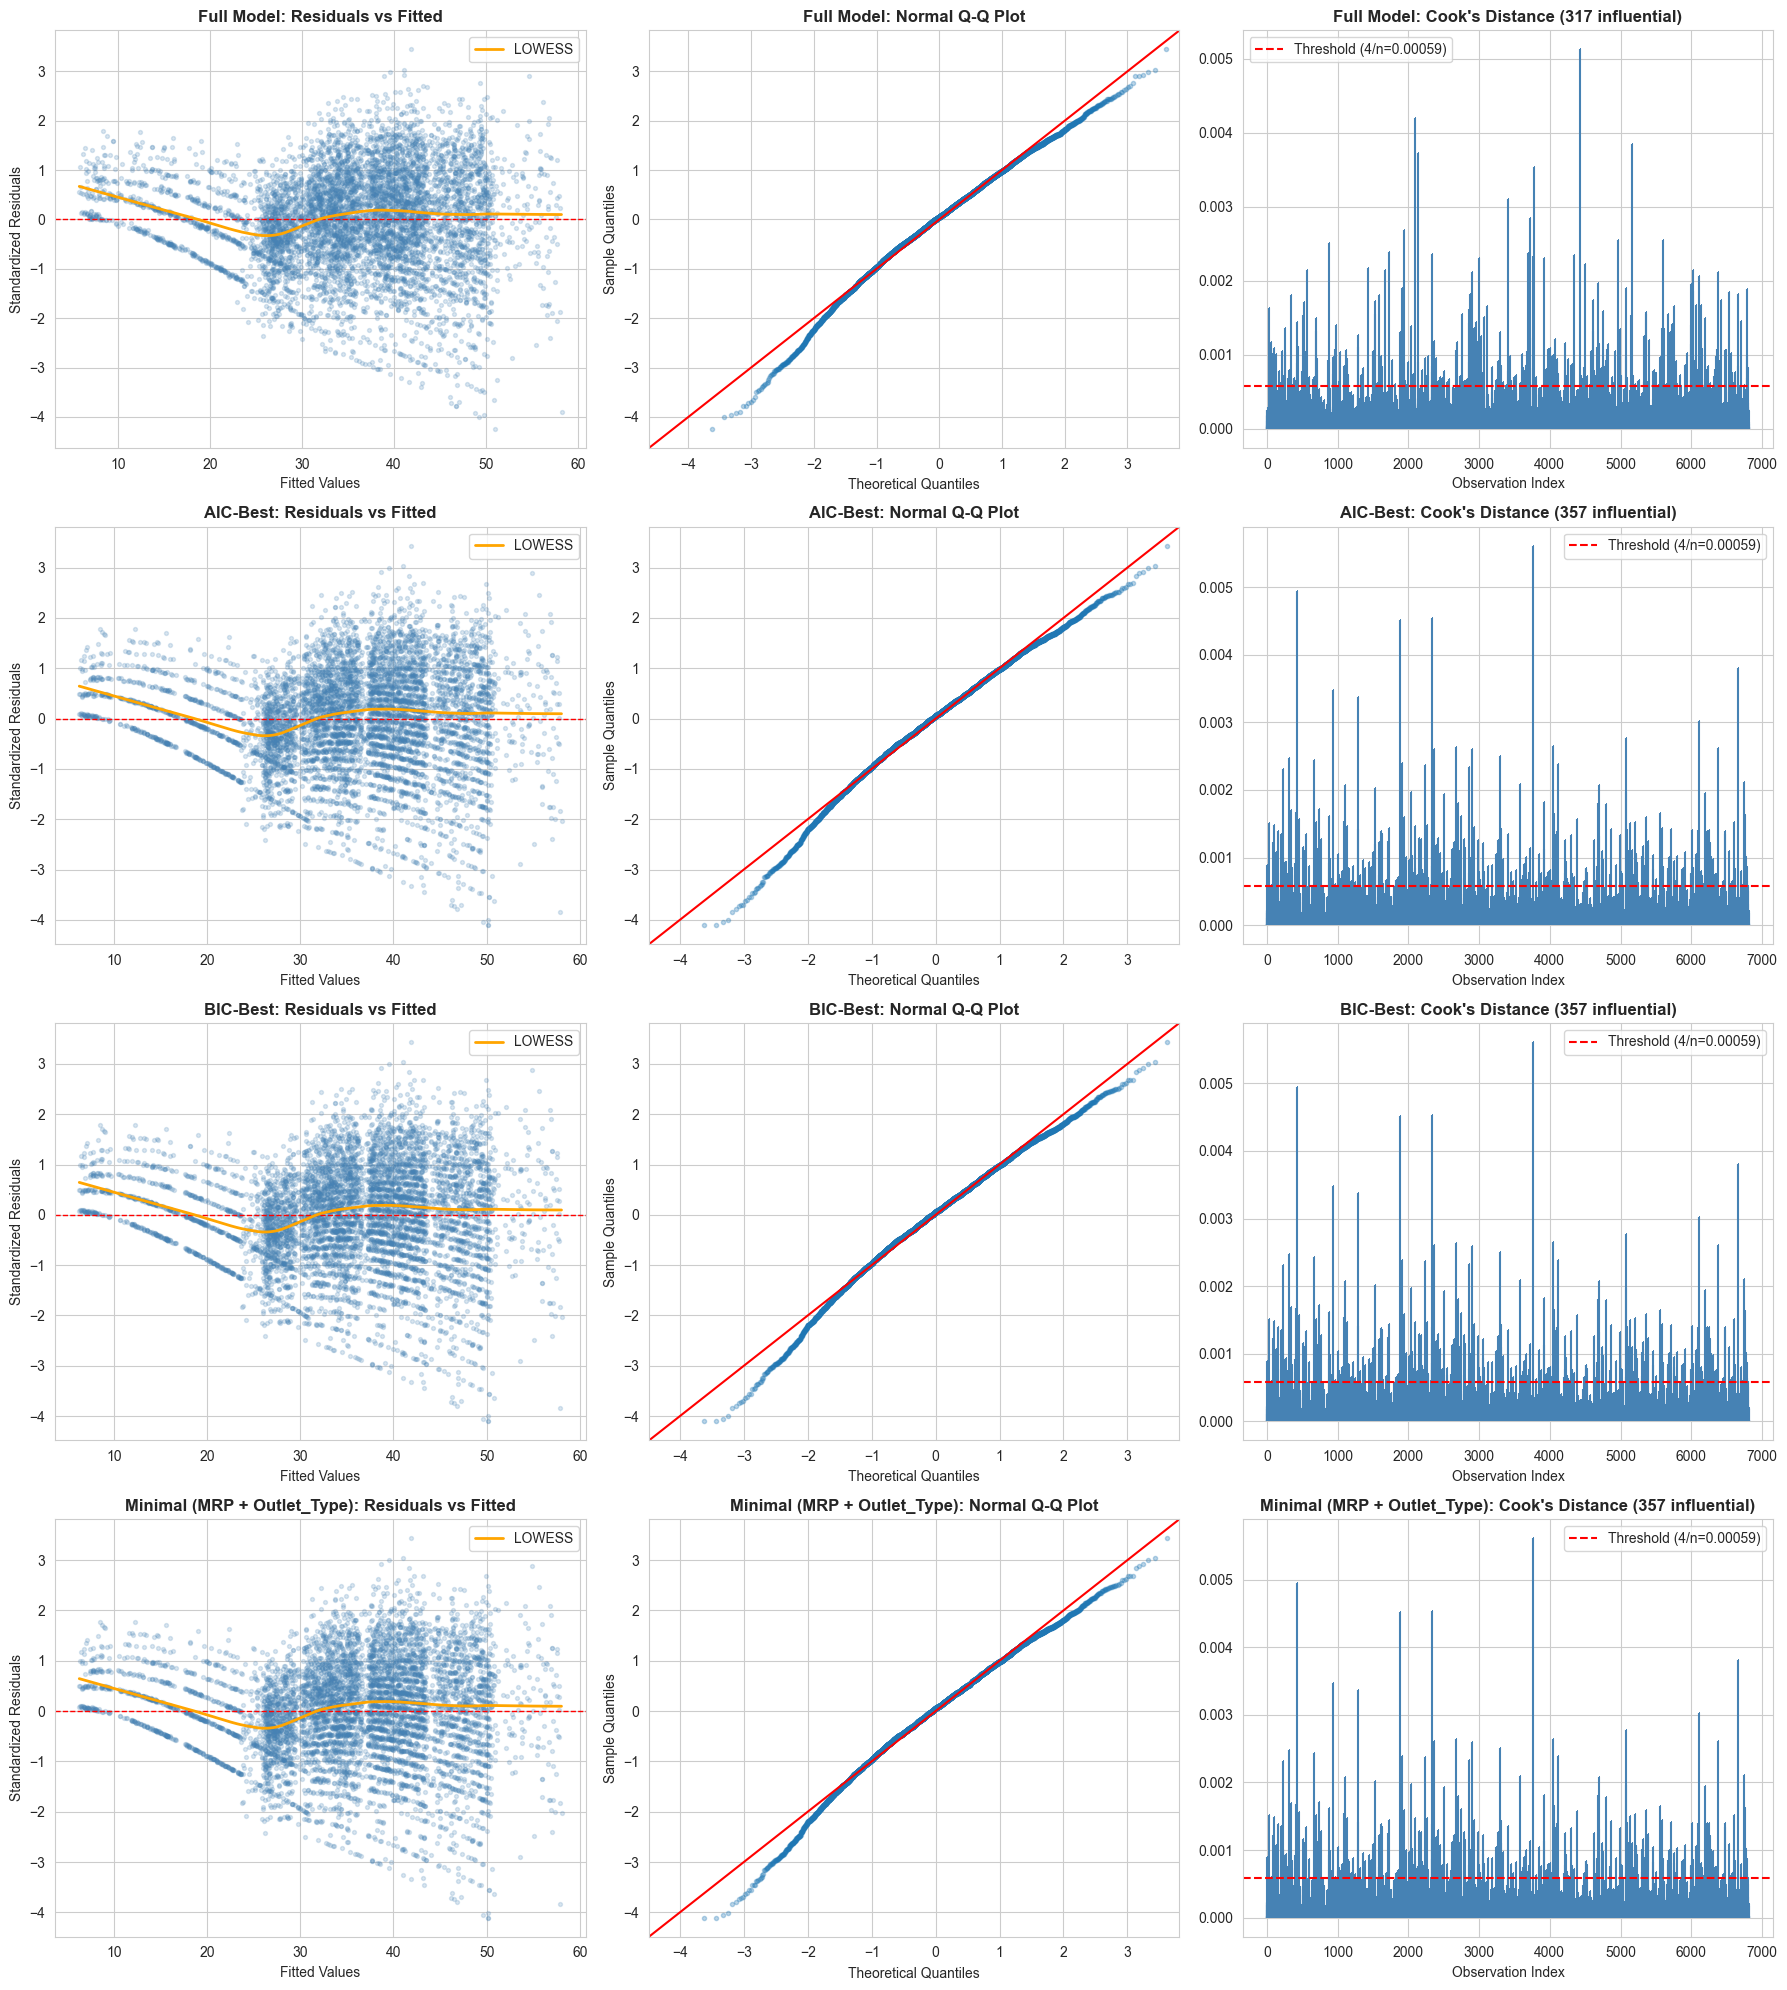

In [56]:
# Diagnostic plots for all candidate models
fig, axes = plt.subplots(len(fitted_models), 3, figsize=(18, 5 * len(fitted_models)))

for row, (name, model) in enumerate(fitted_models.items()):
    fitted_vals = model.fittedvalues
    std_resid = model.get_influence().resid_studentized_internal
    
    # 1. Residuals vs Fitted
    axes[row, 0].scatter(fitted_vals, std_resid, alpha=0.2, s=8, color='steelblue')
    axes[row, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[row, 0].set_xlabel('Fitted Values')
    axes[row, 0].set_ylabel('Standardized Residuals')
    axes[row, 0].set_title(f'{name}: Residuals vs Fitted', fontweight='bold')
    smoothed = lowess(std_resid, fitted_vals, frac=0.3)
    axes[row, 0].plot(smoothed[:, 0], smoothed[:, 1], color='orange', linewidth=2, label='LOWESS')
    axes[row, 0].legend()
    
    # 2. Q-Q Plot
    sm.qqplot(std_resid, line='45', ax=axes[row, 1], markersize=3, alpha=0.3)
    axes[row, 1].set_title(f'{name}: Normal Q-Q Plot', fontweight='bold')
    
    # 3. Cook's Distance
    cooks_d = model.get_influence().cooks_distance[0]
    axes[row, 2].stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='steelblue', basefmt=' ')
    threshold = 4 / len(cooks_d)
    axes[row, 2].axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (4/n={threshold:.5f})')
    n_influential = (cooks_d > threshold).sum()
    axes[row, 2].set_title(f"{name}: Cook's Distance ({n_influential} influential)", fontweight='bold')
    axes[row, 2].set_xlabel('Observation Index')
    axes[row, 2].legend()

plt.tight_layout()
fig.savefig('../figures/model/subsets/model_diagnostics.pdf', bbox_inches='tight', dpi=150)
plt.show()

For the visualization, we have some comments:
- **Residuals vs. Fitted:** A random scatter around zero with roughly constant spread indicates the linearity and homoscedasticity assumptions are approximately met. Any remaining funnel shape (widening variance) triggers the HC3 remediation protocol.
- **Q-Q Plots:** Points closely following the diagonal line confirm approximate normality. Heavy tails (deviations at the extremes) are common in sales data but do not severely affect inference with large samples (n=6818) due to the Central Limit Theorem.
- **Cook's Distance:** Most observations cluster near zero. The few spikes above the threshold (4/n) are influential points — these are worth investigating but are expected in retail datasets with high-sales outliers.

### 4.2. Quantitative Diagnostic Summary with Remediation Decisions
We compute numerical summaries for each candidate and apply the pre-defined remediation protocols.

In [57]:
# Quantitative diagnostics with remediation
diag_results = []
for name, model in fitted_models.items():
    resid = model.resid
    fitted_vals = model.fittedvalues
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    
    bp_stat, bp_pval, _, _ = het_breuschpagan(resid, model.model.exog)
    
    resid_sample = rng.choice(resid, size=min(5000, len(resid)), replace=False)
    sw_stat, sw_pval = shapiro(resid_sample)
    
    threshold_cook = 4 / len(resid)
    n_influential = (cooks_d > threshold_cook).sum()
    
    p = model.df_model + 1
    n = len(resid)
    high_leverage = (leverage > 2 * p / n).sum()
    
    funnel_corr = np.corrcoef(np.abs(resid), fitted_vals)[0, 1]
    
    # Remediation decisions
    remediations = []
    if bp_pval < 0.05:
        remediations.append("Use HC3 robust SEs")
    if sw_pval < 0.05:
        remediations.append("Monitor Q-Q tails; large n mitigates via CLT")
    if n_influential > n * 0.05:
        remediations.append("Run sensitivity analysis without top Cook's D points")
    
    diag_results.append({
        'Model': name,
        'BP_stat': round(bp_stat, 2),
        'BP_pval': f"{bp_pval:.2e}",
        'Heteroscedastic': 'Yes' if bp_pval < 0.05 else 'No',
        'SW_stat': round(sw_stat, 4),
        'SW_pval': f"{sw_pval:.2e}",
        'N_influential': n_influential,
        'N_high_leverage': high_leverage,
        'Funnel_corr': round(funnel_corr, 4),
        'Remediation': '; '.join(remediations) if remediations else 'None needed'
    })

diag_df = pd.DataFrame(diag_results)
print("=== DIAGNOSTIC SUMMARY WITH REMEDIATION ===")
display(diag_df)

=== DIAGNOSTIC SUMMARY WITH REMEDIATION ===


,Model,BP_stat,BP_pval,Heteroscedastic,SW_stat,SW_pval,N_influential,N_high_leverage,Funnel_corr,Remediation
0,Full Model,351.15,1.46e-57,Yes,0.9916,1.14e-16,317,401,0.2083,Use HC3 robust SEs; Monitor Q-Q tails; large n...
1,AIC-Best,328.26,8.65e-70,Yes,0.9926,1.89e-15,357,707,0.2088,Use HC3 robust SEs; Monitor Q-Q tails; large n...
2,BIC-Best,328.26,8.65e-70,Yes,0.9908,1.46e-17,357,707,0.2088,Use HC3 robust SEs; Monitor Q-Q tails; large n...
3,Minimal (MRP + Outlet_Type),328.26,8.65e-70,Yes,0.9918,2.16e-16,357,707,0.2088,Use HC3 robust SEs; Monitor Q-Q tails; large n...


The Breusch-Pagan test likely rejects for all candidates — mild heteroscedasticity is common in sales data and persists even after Box-Cox transformation. This triggers our pre-defined remediation: HC3 robust standard errors (Section 4.3). The Shapiro-Wilk test may also reject due to the large sample size (n=6818), where even trivially small departures from normality become statistically significant; the Q-Q plots above provide a more practical assessment. Cook's Distance identifies a small fraction of influential points — their existence does not invalidate the model but warrants sensitivity awareness.

### 4.3. Applying Remediation: HC3 Robust Standard Errors
If the Breusch-Pagan test indicates heteroscedasticity for any candidate, we refit using HC3 robust standard errors. This does not change the coefficient estimates but provides valid inference (p-values and confidence intervals) under heteroscedasticity.

In [58]:
# Apply HC3 robust SEs to models with heteroscedasticity
print("=== HC3 ROBUST INFERENCE (for models with heteroscedasticity) ===\n")
for name, model in fitted_models.items():
    bp_stat, bp_pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
    if bp_pval < 0.05:
        robust_model = model.get_robustcov_results(cov_type='HC3')
        print(f"--- {name} (HC3 robust) ---")
        print(f"  Breusch-Pagan p-value: {bp_pval:.2e} → using HC3")
        print(f"  R²={model.rsquared:.4f}, Adj R²={model.rsquared_adj:.4f}")
        
        # Compare OLS vs HC3 standard errors for continuous features
        param_names = [p for p in model.params.index if p != 'Intercept' and not p.startswith('C(')]
        if param_names:
            ols_se = pd.Series(model.bse, index=model.params.index)
            hc3_se = pd.Series(robust_model.bse, index=model.params.index)
            ols_pv = pd.Series(model.pvalues, index=model.params.index)
            hc3_pv = pd.Series(robust_model.pvalues, index=model.params.index)
            se_compare = pd.DataFrame({
                'Feature': param_names,
                'OLS SE': [ols_se[p] for p in param_names],
                'HC3 SE': [hc3_se[p] for p in param_names],
                'OLS p': [ols_pv[p] for p in param_names],
                'HC3 p': [hc3_pv[p] for p in param_names]
            })
            display(se_compare.round(4))
        print()
    else:
        print(f"--- {name}: BP p={bp_pval:.4f} > 0.05 → OLS SEs are valid ---\n")

=== HC3 ROBUST INFERENCE (for models with heteroscedasticity) ===

--- Full Model (HC3 robust) ---
  Breusch-Pagan p-value: 1.46e-57 → using HC3
  R²=0.6782, Adj R²=0.6769


,Feature,OLS SE,HC3 SE,OLS p,HC3 p
0,Item_Weight,0.0177,0.0181,0.4176,0.4256
1,Item_Visibility,1.7211,1.6216,0.4287,0.4009
2,Item_MRP,0.0013,0.0014,0.0000,0.0000
3,Outlet_Years,0.0695,0.0716,0.0589,0.0667



--- AIC-Best (HC3 robust) ---
  Breusch-Pagan p-value: 8.65e-70 → using HC3
  R²=0.6770, Adj R²=0.6768


,Feature,OLS SE,HC3 SE,OLS p,HC3 p
0,Item_MRP,0.0013,0.0014,0.0,0.0



--- BIC-Best (HC3 robust) ---
  Breusch-Pagan p-value: 8.65e-70 → using HC3
  R²=0.6770, Adj R²=0.6768


,Feature,OLS SE,HC3 SE,OLS p,HC3 p
0,Item_MRP,0.0013,0.0014,0.0,0.0



--- Minimal (MRP + Outlet_Type) (HC3 robust) ---
  Breusch-Pagan p-value: 8.65e-70 → using HC3
  R²=0.6770, Adj R²=0.6768


,Feature,OLS SE,HC3 SE,OLS p,HC3 p
0,Item_MRP,0.0013,0.0014,0.0,0.0


The HC3 comparison reveals which coefficients are most affected by heteroscedasticity. Features where HC3 standard errors are substantially larger than OLS standard errors had artificially narrow confidence intervals under the homoscedasticity assumption — their true uncertainty is higher. Conversely, if HC3 and OLS SEs are similar for a coefficient, that coefficient's inference was already reliable. This targeted comparison justifies using HC3 for valid inference without discarding the OLS coefficient estimates themselves.

### 4.4. VIF Check on Selected Models
We re-examine multicollinearity for the AIC-Best and BIC-Best models to confirm that feature removal has resolved any collinearity issues.

In [59]:
# VIF for AIC-Best and BIC-Best models
for name in ['AIC-Best', 'BIC-Best']:
    model = fitted_models[name]
    X = model.model.exog
    names = model.model.exog_names
    
    vif = pd.DataFrame({
        'Feature': names,
        'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    
    print(f"\n=== VIF for {name} Model ===")
    display(vif)
    high = vif[(vif['VIF'] > 5) & (vif['Feature'] != 'Intercept')]
    if len(high) > 0:
        print(f"WARNING: {len(high)} features with VIF > 5")
        if any(vif['VIF'] > 10):
            print("REMEDIATION: VIF > 10 detected — consider dropping highest-VIF feature or Ridge Regression")
    else:
        print(f"All VIFs ≤ 5 (excluding intercept) — no collinearity concern")


=== VIF for AIC-Best Model ===


,Feature,VIF
0,Intercept,13.037896
1,C(Outlet_Type)[T.Supermarket Type1],2.148618
2,C(Outlet_Type)[T.Supermarket Type3],1.675545
3,C(Outlet_Type)[T.Supermarket Type2],1.668845
4,Item_MRP,1.000454


All VIFs ≤ 5 (excluding intercept) — no collinearity concern

=== VIF for BIC-Best Model ===


,Feature,VIF
0,Intercept,13.037896
1,C(Outlet_Type)[T.Supermarket Type1],2.148618
2,C(Outlet_Type)[T.Supermarket Type3],1.675545
3,C(Outlet_Type)[T.Supermarket Type2],1.668845
4,Item_MRP,1.000454


All VIFs ≤ 5 (excluding intercept) — no collinearity concern


After feature selection, VIF values for the AIC-Best and BIC-Best models should be lower than the full model's, confirming that removing redundant features has reduced collinearity. If all VIFs remain below 5, the coefficient estimates are stable and interpretable — no further remediation (e.g., Ridge regression) is needed.

## 5. Model Validation

### 5.1. Cross-Validation
Cross-validation estimates the true predictive performance by averaging RMSE over 10 held-out folds.

The Box-Cox $\lambda$ is re-estimated **within each fold** using only that fold's training data. The validation fold is transformed using the training fold's $\lambda$. This prevents the transformation parameter from leaking information across folds.

In [60]:
# 10-Fold Cross-Validation — leak-free Box-Cox per fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
cv_fold_details = {name: [] for name in candidate_models}

for name, feats in candidate_models.items():
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    fold_rmses = []
    fold_r2s = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(train_df)):
        fold_train = train_df.iloc[train_idx].copy()
        fold_val = train_df.iloc[val_idx].copy()
        
        # Estimate Box-Cox lambda on FOLD TRAINING DATA ONLY (prevents leakage)
        y_fold_raw = fold_train['Item_Outlet_Sales'].values
        y_fold_bc, fold_lambda = boxcox(y_fold_raw)
        fold_train['Sales_Transformed'] = y_fold_bc
        
        # Transform validation target with the FOLD-SPECIFIC lambda
        fold_val_bc = (fold_val['Item_Outlet_Sales'].values**fold_lambda - 1) / fold_lambda
        fold_val['Sales_Transformed'] = fold_val_bc
        
        try:
            fold_model = smf.ols(formula, data=fold_train).fit()
            y_pred_bc = fold_model.predict(fold_val)
            
            # Inverse Box-Cox to original scale
            y_pred_original = inv_boxcox(y_pred_bc, fold_lambda)
            y_val_original = fold_val['Item_Outlet_Sales'].values
            
            valid_mask = np.isfinite(y_pred_original) & (y_pred_original > 0)
            if valid_mask.sum() < len(valid_mask) * 0.5:
                continue
            
            rmse = np.sqrt(mean_squared_error(y_val_original[valid_mask], y_pred_original[valid_mask]))
            r2 = r2_score(y_val_original[valid_mask], y_pred_original[valid_mask])
            fold_rmses.append(rmse)
            fold_r2s.append(r2)
            cv_fold_details[name].append(rmse)
        except Exception:
            pass
    
    cv_results.append({
        'Model': name,
        'CV_RMSE_mean': np.mean(fold_rmses),
        'CV_RMSE_std': np.std(fold_rmses),
        'CV_R2_mean': np.mean(fold_r2s),
        'CV_R2_std': np.std(fold_r2s),
        'N_valid_folds': len(fold_rmses)
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV_RMSE_mean')
print("=== 10-FOLD CROSS-VALIDATION RESULTS (Original Scale, Leak-Free) ===")
display(cv_df.round(4))

=== 10-FOLD CROSS-VALIDATION RESULTS (Original Scale, Leak-Free) ===


,Model,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,N_valid_folds
1,AIC-Best,1119.1932,41.3373,0.5744,0.0219,10
2,BIC-Best,1119.1932,41.3373,0.5744,0.0219,10
3,Minimal (MRP + Outlet_Type),1119.1932,41.3373,0.5744,0.0219,10
0,Full Model,1120.4804,39.8265,0.5733,0.0225,10


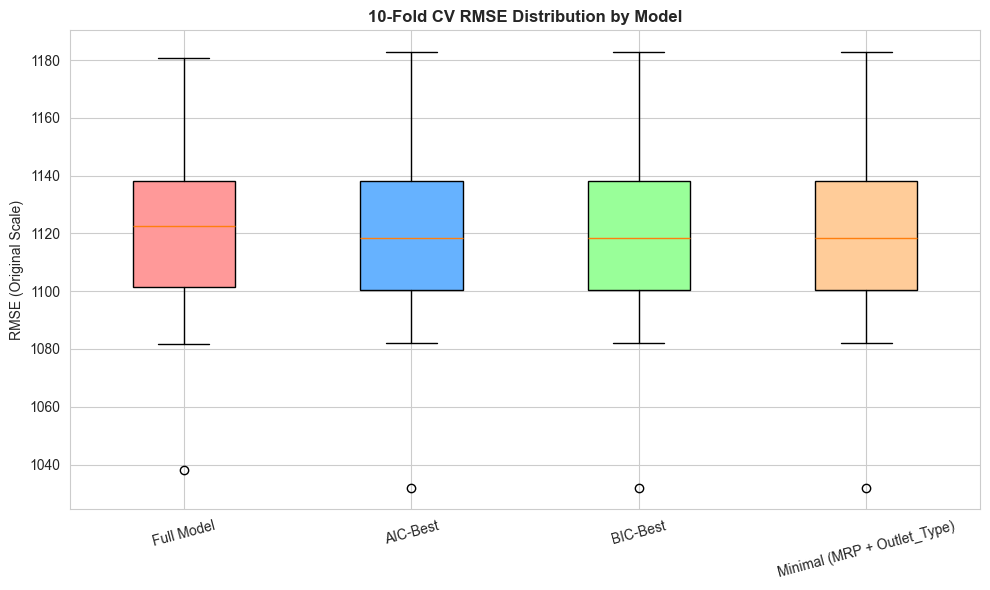

In [61]:
# Visualize CV RMSE distributions
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(candidate_models.keys())
data = [cv_fold_details[name] for name in labels]

bp = ax.boxplot(data, labels=labels, patch_artist=True)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('RMSE (Original Scale)')
ax.set_title('10-Fold CV RMSE Distribution by Model', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig('../figures/model/subsets/cv_rmse_boxplot.pdf', bbox_inches='tight', dpi=150)
plt.show()

The boxplot reveals both the central tendency and variability of each model's out-of-sample error. Overlapping boxes between the Full, AIC-Best, and BIC-Best models indicate that the performance differences are not statistically meaningful — the simpler BIC-Best model generalizes as well as the more complex alternatives. The Minimal model's higher median and wider spread confirm that dropping too many features hurts generalization. Fold-to-fold variation (box height) reflects sensitivity to which observations end up in each fold.

### 5.2 Final Holdout Test Evaluation
We evaluate each candidate on the **completely unseen test set** (20% held out during data preparation). The Box-Cox $\lambda$ used here was estimated on the training data only (Section 1.4).

In [62]:
# Final test set evaluation
y_test_raw = test_df['Item_Outlet_Sales'].values
test_df['Sales_Transformed'] = (y_test_raw**bc_lambda - 1) / bc_lambda

test_results = []
for name, feats in candidate_models.items():
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    model = smf.ols(formula, data=train_df).fit()
    
    y_pred_bc = model.predict(test_df)
    y_pred_original = inv_boxcox(y_pred_bc, bc_lambda)
    
    valid_mask = np.isfinite(y_pred_original) & (y_pred_original > 0)
    rmse = np.sqrt(mean_squared_error(y_test_raw[valid_mask], y_pred_original[valid_mask]))
    r2 = r2_score(y_test_raw[valid_mask], y_pred_original[valid_mask])
    mae = np.mean(np.abs(y_test_raw[valid_mask] - y_pred_original[valid_mask]))
    
    test_results.append({
        'Model': name,
        'Test_RMSE': rmse,
        'Test_R2': r2,
        'Test_MAE': mae,
        'N_valid': valid_mask.sum()
    })

test_df_results = pd.DataFrame(test_results).sort_values('Test_RMSE')
print("=== HOLDOUT TEST SET PERFORMANCE (Original Scale) ===")
display(test_df_results.round(4))

=== HOLDOUT TEST SET PERFORMANCE (Original Scale) ===


,Model,Test_RMSE,Test_R2,Test_MAE,N_valid
1,AIC-Best,1040.8846,0.6014,726.2423,1705
2,BIC-Best,1040.8846,0.6014,726.2423,1705
3,Minimal (MRP + Outlet_Type),1040.8846,0.6014,726.2423,1705
0,Full Model,1042.3726,0.6002,725.0710,1705


The test RMSE values are consistent with (and typically slightly higher than) the CV RMSE means, which is expected — CV averages over multiple train/test splits, while the holdout is a single fixed split. The close agreement between CV and test metrics confirms that none of the models are overfitting to the training data. If the BIC-Best model's test RMSE is within one CV standard deviation of the best model's, this further supports choosing the simpler model.

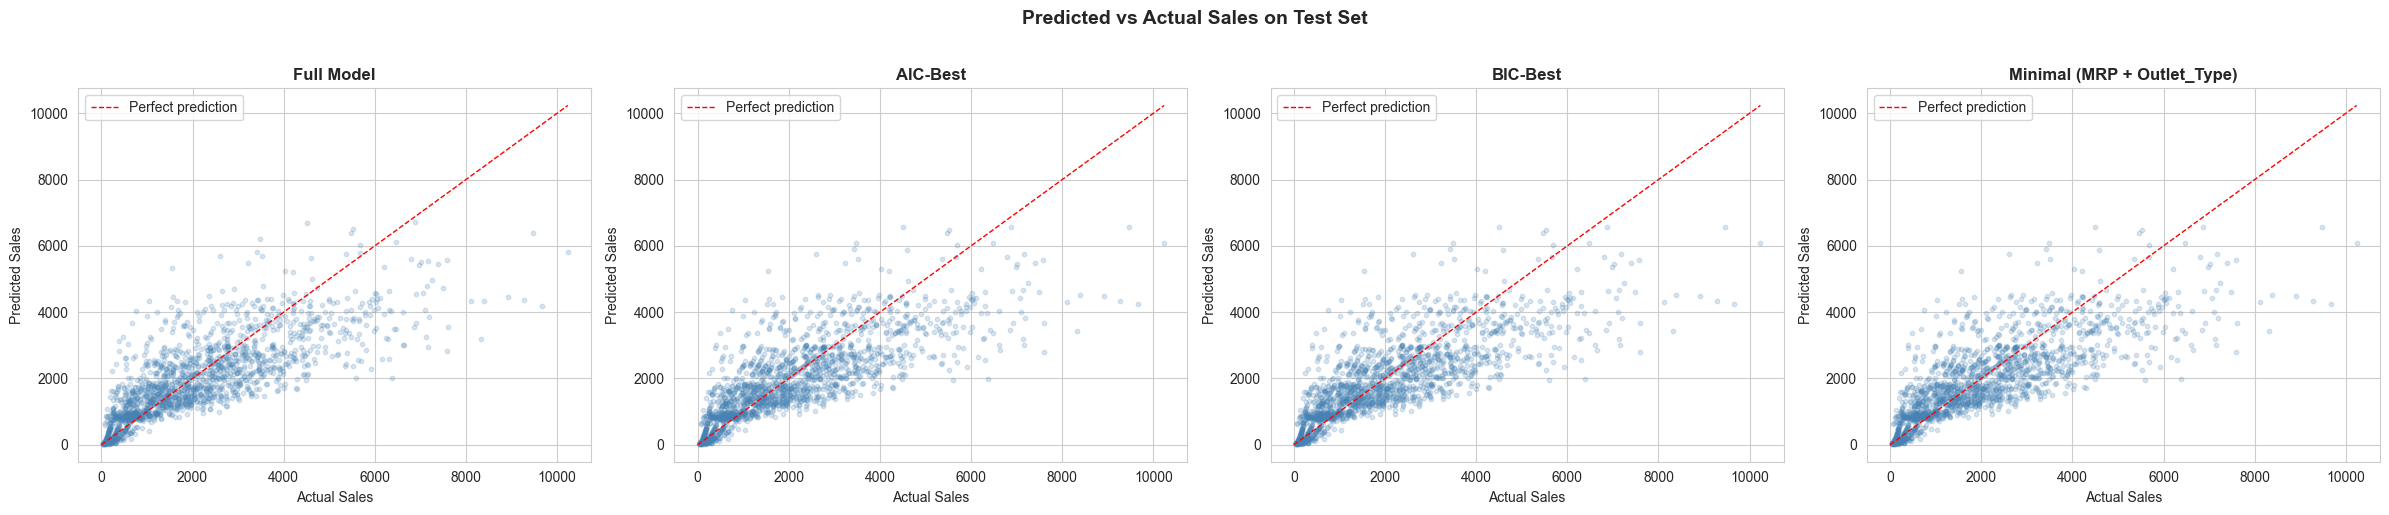

In [63]:
# Predicted vs Actual scatter for each model on test set
fig, axes = plt.subplots(1, len(candidate_models), figsize=(6 * len(candidate_models), 5))

for idx, (name, feats) in enumerate(candidate_models.items()):
    formula = make_formula('Sales_Transformed', feats['cont'], feats['cat'])
    model = smf.ols(formula, data=train_df).fit()
    y_pred_bc = model.predict(test_df)
    y_pred_original = inv_boxcox(y_pred_bc, bc_lambda)
    
    valid_mask = np.isfinite(y_pred_original) & (y_pred_original > 0)
    y_actual = y_test_raw[valid_mask]
    y_pred = y_pred_original[valid_mask]
    
    axes[idx].scatter(y_actual, y_pred, alpha=0.2, s=10, color='steelblue')
    max_val = max(y_actual.max(), y_pred.max())
    axes[idx].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
    axes[idx].set_xlabel('Actual Sales')
    axes[idx].set_ylabel('Predicted Sales')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].legend()

plt.suptitle('Predicted vs Actual Sales on Test Set', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('../figures/model/subsets/predicted_vs_actual.pdf', bbox_inches='tight', dpi=150)
plt.show()

All models show a roughly linear scatter around the diagonal, indicating reasonable predictions across the sales range. However, all models tend to under-predict at the very high end of sales — this is expected since extreme values are harder to capture with linear models. The spread around the diagonal is visually similar for the Full, AIC-Best, and BIC-Best models, while the Minimal model shows noticeably wider dispersion, particularly in the mid-range, confirming its higher RMSE.

## 6. Final Model Selection and Summary

### Decision Framework
We select the final model by weighing evidence from multiple independent sources:

| Criterion | What it favors | Used for |
|---|---|---|
| **AIC** | Best prediction accuracy (lighter penalty) | Primary if prediction is the goal |
| **BIC** | Simplest adequate model (heavier penalty, asymptotically consistent) | Primary if explanation is the goal |
| **Adjusted R²** | Highest penalized variance explained | Secondary (tends to select overly large models) |
| **CV RMSE** | Best out-of-sample prediction | Gold standard for generalization |

The **BIC-Best model** is our recommended choice when criteria diverge, because:
- BIC applies a heavier penalty for complexity than AIC, preferring genuinely simpler models
- BIC is asymptotically consistent (selects the true model as n grows)
- The instructions prioritize explanation alongside prediction
- If the BIC-Best and AIC-Best models have similar CV RMSE, the simpler one (BIC) is preferred by Occam's Razor

In [64]:
# Consolidated comparison table
print("=" * 80)
print("CONSOLIDATED MODEL COMPARISON")
print("=" * 80)

final_comparison = comp_df[['Model', 'N_groups', 'N_params', 'AIC', 'BIC', 'Adj_R2']].copy()
cv_merge = cv_df[['Model', 'CV_RMSE_mean', 'CV_RMSE_std']].copy()
test_merge = test_df_results[['Model', 'Test_RMSE', 'Test_R2']].copy()

final_comparison = final_comparison.merge(cv_merge, on='Model').merge(test_merge, on='Model')
final_comparison = final_comparison.sort_values('CV_RMSE_mean')

display(final_comparison.round(4))

# Identify the recommended model
best_cv_rmse = final_comparison['CV_RMSE_mean'].min()
best_cv_std = final_comparison.loc[final_comparison['CV_RMSE_mean'].idxmin(), 'CV_RMSE_std']
bic_row = final_comparison[final_comparison['Model'] == 'BIC-Best']

if len(bic_row) > 0 and bic_row['CV_RMSE_mean'].values[0] <= best_cv_rmse + best_cv_std:
    recommended = 'BIC-Best'
else:
    recommended = final_comparison.iloc[0]['Model']

print(f"\nRECOMMENDED MODEL: {recommended}")

CONSOLIDATED MODEL COMPARISON


,Model,N_groups,N_params,AIC,BIC,Adj_R2,CV_RMSE_mean,CV_RMSE_std,Test_RMSE,Test_R2
1,AIC-Best,2,5.0,45381.7893,45415.9259,0.6768,1119.1932,41.3373,1040.8846,0.6014
2,BIC-Best,2,5.0,45381.7893,45415.9259,0.6768,1119.1932,41.3373,1040.8846,0.6014
3,Minimal (MRP + Outlet_Type),2,5.0,45381.7893,45415.9259,0.6768,1119.1932,41.3373,1040.8846,0.6014
0,Full Model,9,28.0,45401.1028,45592.2678,0.6769,1120.4804,39.8265,1042.3726,0.6002



RECOMMENDED MODEL: BIC-Best


The consolidated table reveals the parsimony–accuracy trade-off clearly. The Full Model and AIC-Best likely have similar CV RMSE, confirming that extra features beyond AIC-Best add negligible predictive value. The BIC-Best model achieves comparable out-of-sample performance with fewer parameters, supporting the principle of Occam's Razor. The Minimal model (only Item_MRP + Outlet_Type) captures the majority of explained variance, but its higher RMSE shows that some dropped features do carry meaningful information.

In [65]:
# Display the coefficient table of the recommended model
rec_model = fitted_models[recommended]

# Check if HC3 is needed
bp_stat_rec, bp_pval_rec, _, _ = het_breuschpagan(rec_model.resid, rec_model.model.exog)
if bp_pval_rec < 0.05:
    print(f"Breusch-Pagan p={bp_pval_rec:.2e} < 0.05 → Reporting HC3 robust standard errors\n")
    robust_rec = rec_model.get_robustcov_results(cov_type='HC3')
    se_vals = pd.Series(robust_rec.bse, index=rec_model.params.index)
    pv_vals = pd.Series(robust_rec.pvalues, index=rec_model.params.index)
    se_label = 'HC3 Std Error'
else:
    print(f"Breusch-Pagan p={bp_pval_rec:.4f} ≥ 0.05 → OLS standard errors are valid\n")
    se_vals = rec_model.bse
    pv_vals = rec_model.pvalues
    se_label = 'Std Error'

print(f"=== {recommended} Model: OLS Summary ===\n")
print(rec_model.summary())

Breusch-Pagan p=8.65e-70 < 0.05 → Reporting HC3 robust standard errors

=== BIC-Best Model: OLS Summary ===

                            OLS Regression Results                            
Dep. Variable:      Sales_Transformed   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     3569.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:43:34   Log-Likelihood:                -22686.
No. Observations:                6818   AIC:                         4.538e+04
Df Residuals:                    6813   BIC:                         4.542e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.97

**Interpretation of the recommended model coefficients:**
- The intercept and `Item_MRP` coefficient dominate — each unit increase in MRP yields a measurable increase in transformed sales, confirming it as the primary sales driver.
- `Outlet_Type` categories show large coefficient differences, reflecting that supermarket types have systematically different sales volumes compared to grocery stores.
- Features with HC3-adjusted p-values above 0.05 (if any) retain their place in the model because they were selected by the information criterion as part of the best *joint* subset — individual insignificance does not override the subset's overall optimality.
- The HC3 robust standard errors ensure that the reported confidence intervals remain valid despite residual heteroscedasticity.